In [28]:
!pip install seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 783.9 kB/s eta 0:00:00 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.7/118.7 kB 1.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 2.4 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 428.9 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 475.3 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 476.3 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 386.1 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 443.8 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 634.4 kB/s eta 0:00:00a 0:00:01


In [4]:
import pandas as pd
df = pd.read_csv('transformed/parcels.csv')

In [6]:
pd.set_option('display.max_columns', None)

Maybe filter down to just rental properties? (Or maybe not, so that people don't get a pass for not reporting their rentals?)
- Avg survey grade?
- Owner's civil ticket count
    - Percentile compared to this neighborhood
    - Percentile compared to owners with known rentals in the neighborhood
- Owner's civil ticket count, adjusted by number of properties owned (avg)
    - Percentile compared to this neighborhood
    - Percentile compared to owners with known rentals in the neighborhood

In [116]:
import seaborn as sns

agg = [
    'civil_tickets',
    'complaints_health',
    'code_violations',
    'complaints_311',
    'taxdelinquencyamount',
]

t = df[df.activerentalregistrationflag == 1]
# t = df
print(len(t))

pc = t.groupby('parcel_owner').size().reset_index().rename(columns={0: 'parcels'})
o = t.groupby('parcel_owner')[agg].sum().reset_index().merge(pc, on='parcel_owner')

print(len(o))

for col in agg:
    o[col] = o[col] / o.parcels

o.sort_values('taxdelinquencyamount').tail(1000)


16132
11637


,parcel_owner,civil_tickets,complaints_health,code_violations,complaints_311,taxdelinquencyamount,parcels
9311,"ROSE, ANTAUN",1.0,0.0,0.0,1.0,102.890,1
8080,"NORFLEET, TYLER & HANNAH",0.0,0.0,0.0,0.0,103.100,1
846,UNVER LLC,0.0,2.0,0.0,0.0,108.420,1
7087,"M.A.T. CONSTRUCTION AND PROPERTY MANAGEMENT, LLC",0.0,0.0,0.0,0.0,113.300,1
4828,"GILBERT, LAMAR K.",0.0,0.0,0.0,0.0,113.540,1
...,...,...,...,...,...,...,...
6672,LAKEMORELAND APARTMENTS I LLC,4.0,8.0,18.0,24.0,91560.380,1
5539,HITCHCOCK CENTER FOR,0.0,3.0,5.0,0.0,104380.220,1
65,12700 SHKAER REALTY LLC,5.0,84.0,22.0,53.0,136024.060,1
1745,AJAPPJR UPTOWN LLC,0.0,10.5,4.5,0.0,174129.005,2


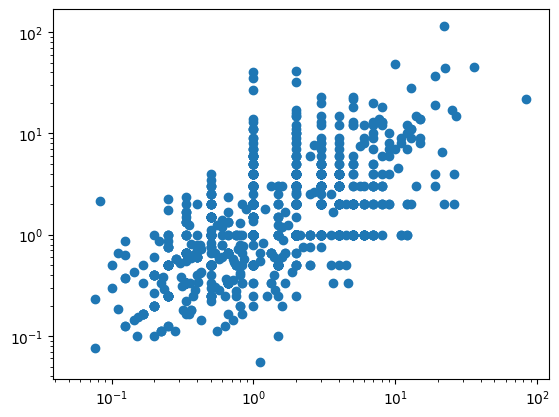

In [76]:
import matplotlib.pyplot as plt

y = o.code_violations
x = o.complaints_health

plt.xscale("log")
plt.yscale("log")

plt.scatter(x, y)